In [1]:
import pandas as pd
import requests
from zipfile import ZipFile
from io import BytesIO
import numpy as np

In [2]:
exe_url = 'https://raw.githubusercontent.com/OTRF/Security-Datasets/master/datasets/atomic/windows/execution/host/psh_python_webserver.zip'
cred_url = 'https://raw.githubusercontent.com/OTRF/Security-Datasets/master/datasets/atomic/windows/credential_access/host/empire_mimikatz_logonpasswords.zip'

In [3]:
# Display all columns and rows
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

## Execution Logs

In [4]:
# Reading the logs from the execution URL
zipFileRequest = requests.get(exe_url)
zipFile = ZipFile(BytesIO(zipFileRequest.content))
datasetJSONPath = zipFile.extract(zipFile.namelist()[0])

# Storing logs into a dataframe
exe_df = pd.read_json(path_or_buf=datasetJSONPath, lines=True)

### Execution Log Exploratory Data Analysis

In [5]:
# Sorting the logs by timestamp in ascending order
exe_data = exe_df.sort_values(by='@timestamp', ascending=True)

# Get all columns in the dataset
exe_columns = exe_data.columns.tolist()
exe_columns

['Message',
 'EventID',
 'SourceName',
 'TimeCreated',
 'Hostname',
 'Task',
 'Level',
 'Keywords',
 'Channel',
 'ProviderGuid',
 '@timestamp',
 'SourcePort',
 'LayerName',
 'SourceAddress',
 'Protocol',
 'ProcessId',
 'LayerRTID',
 'FilterRTID',
 'Application',
 'RemoteMachineID',
 'Direction',
 'DestPort',
 'RemoteUserID',
 'DestAddress',
 'ProcessID',
 'CommandLine',
 'SubjectLogonId',
 'NewProcessId',
 'SubjectDomainName',
 'TargetLogonId',
 'TokenElevationType',
 'SubjectUserSid',
 'NewProcessName',
 'TargetDomainName',
 'TargetUserName',
 'ParentProcessName',
 'TargetUserSid',
 'SubjectUserName',
 'MandatoryLabel',
 'SourceHandleId',
 'TargetHandleId',
 'SourceProcessId',
 'TargetProcessId',
 'ObjectServer',
 'HandleId',
 'ProcessName',
 'RestrictedSidCount',
 'ObjectName',
 'ResourceAttributes',
 'PrivilegeList',
 'TransactionId',
 'AccessMask',
 'ObjectType',
 'AccessReason',
 'AccessList',
 'FilterName',
 'ChangeType',
 'FilterKey',
 'CalloutKey',
 'Action',
 'ProviderName',
 

In [6]:
# Displays information about the dataset
exe_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2395 entries, 1630 to 2394
Columns: 113 entries, Message to QueryResults
dtypes: float64(14), int64(3), object(96)
memory usage: 2.1+ MB


In [7]:
# Gives a description of the dataset
exe_data.describe()

,EventID,Task,Level,SourcePort,Protocol,LayerRTID,FilterRTID,DestPort,ProcessID,RestrictedSidCount,FilterId,Weight,LayerId,SourceThreadId,ParentProcessId,TerminalSessionId,QueryStatus
count,2395.000000,2395.000000,2395.000000,9.000000,9.0,9.000000,9.000000,4.000000,4.000000,322.000000,8.00000,8.000000e+00,8.00000,451.000000,3.0,3.0,1.0
mean,3179.144885,8709.569937,1.281002,43344.222222,6.0,41.333333,40317.444444,1734.500000,2172.000000,4.860248,81936.50000,1.037687e+19,42.00000,6886.962306,9320.0,2.0,0.0
std,2176.158721,5973.294724,1.866681,27035.151603,0.0,5.000000,38427.887088,1910.452041,1307.121009,0.825435,2.44949,7.039414e+14,3.70328,4782.408983,0.0,0.0,NaN
min,1.000000,1.000000,0.000000,8000.000000,6.0,36.000000,0.000000,80.000000,1040.000000,0.000000,81933.00000,1.037629e+19,36.00000,1060.000000,9320.0,2.0,0.0
25%,10.000000,10.000000,0.000000,8000.000000,6.0,36.000000,0.000000,80.000000,1040.000000,5.000000,81934.75000,1.037640e+19,39.50000,2204.000000,9320.0,2.0,0.0
50%,4658.000000,12801.000000,0.000000,52342.000000,6.0,42.000000,69895.000000,1734.500000,2172.000000,5.000000,81936.50000,1.037665e+19,43.00000,5884.000000,9320.0,2.0,0.0
75%,4663.000000,12801.000000,4.000000,65353.000000,6.0,44.000000,70566.000000,3389.000000,3304.000000,5.000000,81938.25000,1.037703e+19,44.50000,12076.000000,9320.0,2.0,0.0
max,5447.000000,13573.000000,4.000000,65354.000000,6.0,48.000000,81935.000000,3389.000000,3304.000000,5.000000,81940.00000,1.037798e+19,46.00000,12724.000000,9320.0,2.0,0.0


In [8]:
# Returns the shape of the datatset (rows, columns)
exe_data.shape

(2395, 113)

In [9]:
# Display first 100 rows
exe_data.head(100)

,Message,EventID,SourceName,TimeCreated,Hostname,Task,Level,Keywords,Channel,ProviderGuid,@timestamp,SourcePort,LayerName,SourceAddress,Protocol,ProcessId,LayerRTID,FilterRTID,Application,RemoteMachineID,Direction,DestPort,RemoteUserID,DestAddress,ProcessID,CommandLine,SubjectLogonId,NewProcessId,SubjectDomainName,TargetLogonId,TokenElevationType,SubjectUserSid,NewProcessName,TargetDomainName,TargetUserName,ParentProcessName,TargetUserSid,SubjectUserName,MandatoryLabel,SourceHandleId,TargetHandleId,SourceProcessId,TargetProcessId,ObjectServer,HandleId,ProcessName,RestrictedSidCount,ObjectName,ResourceAttributes,PrivilegeList,TransactionId,AccessMask,ObjectType,AccessReason,AccessList,FilterName,ChangeType,FilterKey,CalloutKey,Action,ProviderName,ProviderKey,Conditions,FilterId,UserSid,UserName,CalloutName,FilterType,Weight,LayerKey,LayerId,RuleId,RuleName,ProfileChanged,Status,GrantedAccess,SourceThreadId,SourceImage,CallTrace,UtcTime,TargetProcessGUID,SourceProcessGUID,TargetImage,ProcessGuid,Image,Details,EventType,TargetObject,Description,Product,Company,OriginalFileName,User,ParentProcessId,IntegrityLevel,CurrentDirectory,Hashes,ParentCommandLine,TerminalSessionId,ParentImage,FileVersion,ParentProcessGuid,LogonGuid,LogonId,Signature,ImageLoaded,SignatureStatus,Signed,TargetFilename,CreationUtcTime,QueryName,QueryStatus,QueryResults
1630,Process accessed:\r\nRuleName: -\r\nUtcTime: 2...,10,Microsoft-Windows-Sysmon,2020-10-29T12:16:07.257Z,WORKSTATION5,10,4,0x8000000000000000,Microsoft-Windows-Sysmon/Operational,{5770385f-c22a-43e0-bf4c-06f5698ffbd9},2020-10-29T12:16:07.257Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,944,9372,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,NaN,NaN,0x1000,1060.0,C:\windows\system32\svchost.exe,C:\windows\SYSTEM32\ntdll.dll+9c584|C:\windows...,2020-10-29 04:16:07.256,{39e4a257-4169-5f9a-2136-000000000700},{39e4a257-f132-5f8b-1000-000000000700},C:\windows\system32\backgroundTaskHost.exe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1629,Process accessed:\r\nRuleName: -\r\nUtcTime: 2...,10,Microsoft-Windows-Sysmon,2020-10-29T12:16:07.257Z,WORKSTATION5,10,4,0x8000000000000000,Microsoft-Windows-Sysmon/Operational,{5770385f-c22a-43e0-bf4c-06f5698ffbd9},2020-10-29T12:16:07.257Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,944,4368,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,NaN,NaN,0x1000,1060.0,C:\windows\system32\svchost.exe,C:\windows\SYSTEM32\ntdll.dll+9c584|C:\windows...,2020-10-29 04:16:07.256,{39e4a257-f247-5f8b-d300-000000000700},{39e4a257-f132-5f8b-1000-000000000700},C:\Windows\SystemApps\InputApp_cw5n1h2txyewy\W...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,The audit log was cleared.\r\nSubject:\r\n\tSe...,1102,Microsoft-Windows-Eventlog,2020-10-29T12:16:07.900Z,WORKSTATION5,104,4,0x4020000000000000,Security,{fc65ddd8-d6ef-4962-83d5-6e5cfe9ce148},2020-10-29T12:16:07.900Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1632,Process accessed:\r\nRuleName: -\r\nUtcTime: 2...,10,Microsoft-Windows-Sysmon,2020-10-29T12:16:08.260Z,WORKSTATION5,10,4,0x8000000000000000,Microsoft-Windows-Sysmon/Operational,{5770385f-c22a-43e0-bf4c-06f5698ffbd9},2020-10-29T12:16:08.260Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

In [10]:
# Display last 100 rows
exe_data.tail(100)

,Message,EventID,SourceName,TimeCreated,Hostname,Task,Level,Keywords,Channel,ProviderGuid,@timestamp,SourcePort,LayerName,SourceAddress,Protocol,ProcessId,LayerRTID,FilterRTID,Application,RemoteMachineID,Direction,DestPort,RemoteUserID,DestAddress,ProcessID,CommandLine,SubjectLogonId,NewProcessId,SubjectDomainName,TargetLogonId,TokenElevationType,SubjectUserSid,NewProcessName,TargetDomainName,TargetUserName,ParentProcessName,TargetUserSid,SubjectUserName,MandatoryLabel,SourceHandleId,TargetHandleId,SourceProcessId,TargetProcessId,ObjectServer,HandleId,ProcessName,RestrictedSidCount,ObjectName,ResourceAttributes,PrivilegeList,TransactionId,AccessMask,ObjectType,AccessReason,AccessList,FilterName,ChangeType,FilterKey,CalloutKey,Action,ProviderName,ProviderKey,Conditions,FilterId,UserSid,UserName,CalloutName,FilterType,Weight,LayerKey,LayerId,RuleId,RuleName,ProfileChanged,Status,GrantedAccess,SourceThreadId,SourceImage,CallTrace,UtcTime,TargetProcessGUID,SourceProcessGUID,TargetImage,ProcessGuid,Image,Details,EventType,TargetObject,Description,Product,Company,OriginalFileName,User,ParentProcessId,IntegrityLevel,CurrentDirectory,Hashes,ParentCommandLine,TerminalSessionId,ParentImage,FileVersion,ParentProcessGuid,LogonGuid,LogonId,Signature,ImageLoaded,SignatureStatus,Signed,TargetFilename,CreationUtcTime,QueryName,QueryStatus,QueryResults
2295,Process accessed:\r\nRuleName: -\r\nUtcTime: 2...,10,Microsoft-Windows-Sysmon,2020-10-29T12:16:18.665Z,WORKSTATION5,10,4,0x8000000000000000,Microsoft-Windows-Sysmon/Operational,{5770385f-c22a-43e0-bf4c-06f5698ffbd9},2020-10-29T12:16:18.665Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1556,2072,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,NaN,NaN,0x2000,2204.0,C:\windows\system32\svchost.exe,C:\windows\SYSTEM32\ntdll.dll+9c584|C:\windows...,2020-10-29 04:16:18.650,{39e4a257-f1ad-5f8b-9500-000000000700},{39e4a257-f133-5f8b-3100-000000000700},C:\windows\system32\svchost.exe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2296,Process accessed:\r\nRuleName: -\r\nUtcTime: 2...,10,Microsoft-Windows-Sysmon,2020-10-29T12:16:18.666Z,WORKSTATION5,10,4,0x8000000000000000,Microsoft-Windows-Sysmon/Operational,{5770385f-c22a-43e0-bf4c-06f5698ffbd9},2020-10-29T12:16:18.666Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1556,816,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,NaN,NaN,0x2000,2204.0,C:\windows\system32\svchost.exe,C:\windows\SYSTEM32\ntdll.dll+9c584|C:\windows...,2020-10-29 04:16:18.665,{39e4a257-f1af-5f8b-9700-000000000700},{39e4a257-f133-5f8b-3100-000000000700},C:\windows\Sysmon.exe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2297,Process accessed:\r\nRuleName: -\r\nUtcTime: 2...,10,Microsoft-Windows-Sysmon,2020-10-29T12:16:18.666Z,WORKSTATION5,10,4,0x8000000000000000,Microsoft-Windows-Sysmon/Operational,{5770385f-c22a-43e0-bf4c-06f5698ffbd9},2020-10-29T12:16:18.666Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1556,2920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,NaN,NaN,0x2000,2204.0,C:\windows\system32\svchost.exe,C:\windows\SYSTEM32\ntdll.dll+9c584|C:\windows...,2020-10-29 04:16:18.665,{39e4a257-f1b0-5f8b-9a00-000000000700},{39e4a257-f133-5f8b-3100-000000000700},C:\windows\System32\rdpclip.exe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2298,Process accessed:\r\nRuleName: -\r\nUtcTime: 2...,10,Microsoft-Windows-Sysmon,2020-10-29T12:

In [11]:
# Checks which feature has ONLY NaN values
exe_data.isna().all()

Message               False
EventID               False
SourceName            False
TimeCreated           False
Hostname              False
Task                  False
Level                 False
Keywords              False
Channel               False
ProviderGuid          False
@timestamp            False
SourcePort            False
LayerName             False
SourceAddress         False
Protocol              False
ProcessId             False
LayerRTID             False
FilterRTID            False
Application           False
RemoteMachineID       False
Direction             False
DestPort              False
RemoteUserID          False
DestAddress           False
ProcessID             False
CommandLine           False
SubjectLogonId        False
NewProcessId          False
SubjectDomainName     False
TargetLogonId         False
TokenElevationType    False
SubjectUserSid        False
NewProcessName        False
TargetDomainName      False
TargetUserName        False
ParentProcessName   

In [12]:
# Algorithm to count the number of occurrences of each value in each feature and save it to a text file
'''for feature in exe_data.columns.to_list():
    count = exe_data[feature].value_counts()

    # Replace spaces in feature names to avoid invalid filenames
    safe_feature_name = feature.replace(" ", "_")

    with open(f"{safe_feature_name}.txt", "w") as f:
        f.write(count.to_string())'''

'for feature in exe_data.columns.to_list():\n    count = exe_data[feature].value_counts()\n\n    # Replace spaces in feature names to avoid invalid filenames\n    safe_feature_name = feature.replace(" ", "_")\n\n    with open(f"{safe_feature_name}.txt", "w") as f:\n        f.write(count.to_string())'

<u>Event Distribution Analysis</u><br>
@timestamp<br>
EventID

In [13]:
# Creates a new dataframe with only the timestamp and EventID columns to analyze the distribution of events over time
event_distributions = exe_data[['@timestamp','EventID']]

In [14]:
# Displaying first 100 rows
event_distributions.head(100)

,@timestamp,EventID
1630,2020-10-29T12:16:07.257Z,10
1629,2020-10-29T12:16:07.257Z,10
0,2020-10-29T12:16:07.900Z,1102
1632,2020-10-29T12:16:08.260Z,10
1631,2020-10-29T12:16:08.260Z,10
1633,2020-10-29T12:16:08.500Z,10
1636,2020-10-29T12:16:08.500Z,10
1637,2020-10-29T12:16:08.500Z,10
1638,2020-10-29T12:16:08.500Z,10
1639,2020-10-29T12:16:08.500Z,10


In [15]:
# Displaying last 100 rows
event_distributions.tail(100)

,@timestamp,EventID
2295,2020-10-29T12:16:18.665Z,10
2296,2020-10-29T12:16:18.666Z,10
2297,2020-10-29T12:16:18.666Z,10
2298,2020-10-29T12:16:18.667Z,10
2299,2020-10-29T12:16:18.668Z,10
2300,2020-10-29T12:16:18.669Z,10
2301,2020-10-29T12:16:18.670Z,10
2302,2020-10-29T12:16:18.671Z,10
2303,2020-10-29T12:16:18.672Z,10
2304,2020-10-29T12:16:18.673Z,10


In [16]:
# Getting the counts of each unique EventID
counts = event_distributions['EventID'].value_counts()
counts

EventID
4658    642
10      451
4656    322
4690    320
4663    320
7       254
12       28
13       23
5447      8
5156      4
11        4
5158      4
4688      3
1         3
4689      2
4946      2
5         2
1102      1
5154      1
22        1
Name: count, dtype: int64

In [17]:
# Subset for task analysis
event_tasks = exe_data[['@timestamp','EventID','Task']]

In [18]:
# Displays first 100 rows
event_tasks.head(100)

,@timestamp,EventID,Task
1630,2020-10-29T12:16:07.257Z,10,10
1629,2020-10-29T12:16:07.257Z,10,10
0,2020-10-29T12:16:07.900Z,1102,104
1632,2020-10-29T12:16:08.260Z,10,10
1631,2020-10-29T12:16:08.260Z,10,10
1633,2020-10-29T12:16:08.500Z,10,10
1636,2020-10-29T12:16:08.500Z,10,10
1637,2020-10-29T12:16:08.500Z,10,10
1638,2020-10-29T12:16:08.500Z,10,10
1639,2020-10-29T12:16:08.500Z,10,10


In [19]:
# Displays last 100 rows
event_tasks.tail(100)

,@timestamp,EventID,Task
2295,2020-10-29T12:16:18.665Z,10,10
2296,2020-10-29T12:16:18.666Z,10,10
2297,2020-10-29T12:16:18.666Z,10,10
2298,2020-10-29T12:16:18.667Z,10,10
2299,2020-10-29T12:16:18.668Z,10,10
2300,2020-10-29T12:16:18.669Z,10,10
2301,2020-10-29T12:16:18.670Z,10,10
2302,2020-10-29T12:16:18.671Z,10,10
2303,2020-10-29T12:16:18.672Z,10,10
2304,2020-10-29T12:16:18.673Z,10,10


<u>Time-Based Analysis</u><br>
TimeCreated<br>
@timestamp<br>
UtcTime

In [20]:
# Subset for time analysis
time = exe_data[['@timestamp','EventID','TimeCreated','UtcTime']]

In [21]:
# Display first 100 rows
time.head(100)

,@timestamp,EventID,TimeCreated,UtcTime
1630,2020-10-29T12:16:07.257Z,10,2020-10-29T12:16:07.257Z,2020-10-29 04:16:07.256
1629,2020-10-29T12:16:07.257Z,10,2020-10-29T12:16:07.257Z,2020-10-29 04:16:07.256
0,2020-10-29T12:16:07.900Z,1102,2020-10-29T12:16:07.900Z,NaN
1632,2020-10-29T12:16:08.260Z,10,2020-10-29T12:16:08.260Z,2020-10-29 04:16:08.259
1631,2020-10-29T12:16:08.260Z,10,2020-10-29T12:16:08.260Z,2020-10-29 04:16:08.259
1633,2020-10-29T12:16:08.500Z,10,2020-10-29T12:16:08.500Z,2020-10-29 04:16:08.494
1636,2020-10-29T12:16:08.500Z,10,2020-10-29T12:16:08.500Z,2020-10-29 04:16:08.494
1637,2020-10-29T12:16:08.500Z,10,2020-10-29T12:16:08.500Z,2020-10-29 04:16:08.494
1638,2020-10-29T12:16:08.500Z,10,2020-10-29T12:16:08.500Z,2020-10-29 04:16:08.494
1639,2020-10-29T12:16:08.500Z,10,2020-10-29T12:16:08.500Z,2020-10-29 04:16:08.494


In [22]:
# Display last 100 rows
time.tail(100)

,@timestamp,EventID,TimeCreated,UtcTime
2295,2020-10-29T12:16:18.665Z,10,2020-10-29T12:16:18.665Z,2020-10-29 04:16:18.650
2296,2020-10-29T12:16:18.666Z,10,2020-10-29T12:16:18.666Z,2020-10-29 04:16:18.665
2297,2020-10-29T12:16:18.666Z,10,2020-10-29T12:16:18.666Z,2020-10-29 04:16:18.665
2298,2020-10-29T12:16:18.667Z,10,2020-10-29T12:16:18.667Z,2020-10-29 04:16:18.665
2299,2020-10-29T12:16:18.668Z,10,2020-10-29T12:16:18.668Z,2020-10-29 04:16:18.665
2300,2020-10-29T12:16:18.669Z,10,2020-10-29T12:16:18.669Z,2020-10-29 04:16:18.665
2301,2020-10-29T12:16:18.670Z,10,2020-10-29T12:16:18.670Z,2020-10-29 04:16:18.665
2302,2020-10-29T12:16:18.671Z,10,2020-10-29T12:16:18.671Z,2020-10-29 04:16:18.665
2303,2020-10-29T12:16:18.672Z,10,2020-10-29T12:16:18.672Z,2020-10-29 04:16:18.665
2304,2020-10-29T12:16:18.673Z,10,2020-10-29T12:16:18.673Z,2020-10-29 04:16:18.665


<u>User Activity Analysis</u><br>
UserName<br>
SubjectUserName<br>
TargetUserName<br>
LogonId<br>
TokenElevationType

In [23]:
# Subset for user activity analysis
user_activity = exe_data[['@timestamp','EventID','UserName','SubjectUserName','TargetUserName','LogonId','TokenElevationType']]

In [24]:
# Displays first 100 rows
user_activity.head(100)

,@timestamp,EventID,UserName,SubjectUserName,TargetUserName,LogonId,TokenElevationType
1630,2020-10-29T12:16:07.257Z,10,NaN,NaN,NaN,NaN,NaN
1629,2020-10-29T12:16:07.257Z,10,NaN,NaN,NaN,NaN,NaN
0,2020-10-29T12:16:07.900Z,1102,NaN,NaN,NaN,NaN,NaN
1632,2020-10-29T12:16:08.260Z,10,NaN,NaN,NaN,NaN,NaN
1631,2020-10-29T12:16:08.260Z,10,NaN,NaN,NaN,NaN,NaN
1633,2020-10-29T12:16:08.500Z,10,NaN,NaN,NaN,NaN,NaN
1636,2020-10-29T12:16:08.500Z,10,NaN,NaN,NaN,NaN,NaN
1637,2020-10-29T12:16:08.500Z,10,NaN,NaN,NaN,NaN,NaN
1638,2020-10-29T12:16:08.500Z,10,NaN,NaN,NaN,NaN,NaN
1639,2020-10-29T12:16:08.500Z,10,NaN,NaN,NaN,NaN,NaN


In [25]:
# Displays last 100 rows
user_activity.tail(100)

,@timestamp,EventID,UserName,SubjectUserName,TargetUserName,LogonId,TokenElevationType
2295,2020-10-29T12:16:18.665Z,10,NaN,NaN,NaN,NaN,NaN
2296,2020-10-29T12:16:18.666Z,10,NaN,NaN,NaN,NaN,NaN
2297,2020-10-29T12:16:18.666Z,10,NaN,NaN,NaN,NaN,NaN
2298,2020-10-29T12:16:18.667Z,10,NaN,NaN,NaN,NaN,NaN
2299,2020-10-29T12:16:18.668Z,10,NaN,NaN,NaN,NaN,NaN
2300,2020-10-29T12:16:18.669Z,10,NaN,NaN,NaN,NaN,NaN
2301,2020-10-29T12:16:18.670Z,10,NaN,NaN,NaN,NaN,NaN
2302,2020-10-29T12:16:18.671Z,10,NaN,NaN,NaN,NaN,NaN
2303,2020-10-29T12:16:18.672Z,10,NaN,NaN,NaN,NaN,NaN
2304,2020-10-29T12:16:18.673Z,10,NaN,NaN,NaN,NaN,NaN


<u>Process Behavior Analysis</u><br>
@timestamp<br>
EventID<br>
Image<br>
ProcessName<br>
CommandLine<br>
ParentImage<br>
ParentProcessName<br>
IntegrityLevel<br>
TokenElevationType<br>
Hashes<br>
SignatureStatus<br>
Signed

In [26]:
# Creates a subset dataframe for process behavior analysis
process_behavior = exe_data[['@timestamp','EventID','Image','ProcessName','CommandLine','ParentImage','ParentProcessName','IntegrityLevel','TokenElevationType','Hashes','SignatureStatus','Signed']]

In [27]:
# Displays the first 100 rows of the subset dataframe
process_behavior.head(100)

,@timestamp,EventID,Image,ProcessName,CommandLine,ParentImage,ParentProcessName,IntegrityLevel,TokenElevationType,Hashes,SignatureStatus,Signed
1630,2020-10-29T12:16:07.257Z,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1629,2020-10-29T12:16:07.257Z,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,2020-10-29T12:16:07.900Z,1102,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1632,2020-10-29T12:16:08.260Z,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1631,2020-10-29T12:16:08.260Z,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1633,2020-10-29T12:16:08.500Z,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1636,2020-10-29T12:16:08.500Z,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1637,2020-10-29T12:16:08.500Z,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1638,2020-10-29T12:16:08.500Z,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1639,2020-10-29T12:16:08.500Z,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
# Display the last 100 rows of the subset dataframe
process_behavior.tail(100)

,@timestamp,EventID,Image,ProcessName,CommandLine,ParentImage,ParentProcessName,IntegrityLevel,TokenElevationType,Hashes,SignatureStatus,Signed
2295,2020-10-29T12:16:18.665Z,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2296,2020-10-29T12:16:18.666Z,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2297,2020-10-29T12:16:18.666Z,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2298,2020-10-29T12:16:18.667Z,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2299,2020-10-29T12:16:18.668Z,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2300,2020-10-29T12:16:18.669Z,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2301,2020-10-29T12:16:18.670Z,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2302,2020-10-29T12:16:18.671Z,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2303,2020-10-29T12:16:18.672Z,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2304,2020-10-29T12:16:18.673Z,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<u>Network Behavior Analysis</u><br>
SourceAddress<br>
DestAddress<br>
SourcePort<br>
DestPort<br>
Protocol<br>
Direction<br>

In [29]:
# Creates a new dataframe for network behavior analysis
network_behavior = exe_data[['@timestamp','EventID','SourceAddress','DestAddress','SourcePort','DestPort','Protocol','Direction']]

In [30]:
# Displays the first 100 rows
network_behavior.head(100)

,@timestamp,EventID,SourceAddress,DestAddress,SourcePort,DestPort,Protocol,Direction
1630,2020-10-29T12:16:07.257Z,10,NaN,NaN,NaN,NaN,NaN,NaN
1629,2020-10-29T12:16:07.257Z,10,NaN,NaN,NaN,NaN,NaN,NaN
0,2020-10-29T12:16:07.900Z,1102,NaN,NaN,NaN,NaN,NaN,NaN
1632,2020-10-29T12:16:08.260Z,10,NaN,NaN,NaN,NaN,NaN,NaN
1631,2020-10-29T12:16:08.260Z,10,NaN,NaN,NaN,NaN,NaN,NaN
1633,2020-10-29T12:16:08.500Z,10,NaN,NaN,NaN,NaN,NaN,NaN
1636,2020-10-29T12:16:08.500Z,10,NaN,NaN,NaN,NaN,NaN,NaN
1637,2020-10-29T12:16:08.500Z,10,NaN,NaN,NaN,NaN,NaN,NaN
1638,2020-10-29T12:16:08.500Z,10,NaN,NaN,NaN,NaN,NaN,NaN
1639,2020-10-29T12:16:08.500Z,10,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
# Displays the last 100 rows
network_behavior.tail(100)

,@timestamp,EventID,SourceAddress,DestAddress,SourcePort,DestPort,Protocol,Direction
2295,2020-10-29T12:16:18.665Z,10,NaN,NaN,NaN,NaN,NaN,NaN
2296,2020-10-29T12:16:18.666Z,10,NaN,NaN,NaN,NaN,NaN,NaN
2297,2020-10-29T12:16:18.666Z,10,NaN,NaN,NaN,NaN,NaN,NaN
2298,2020-10-29T12:16:18.667Z,10,NaN,NaN,NaN,NaN,NaN,NaN
2299,2020-10-29T12:16:18.668Z,10,NaN,NaN,NaN,NaN,NaN,NaN
2300,2020-10-29T12:16:18.669Z,10,NaN,NaN,NaN,NaN,NaN,NaN
2301,2020-10-29T12:16:18.670Z,10,NaN,NaN,NaN,NaN,NaN,NaN
2302,2020-10-29T12:16:18.671Z,10,NaN,NaN,NaN,NaN,NaN,NaN
2303,2020-10-29T12:16:18.672Z,10,NaN,NaN,NaN,NaN,NaN,NaN
2304,2020-10-29T12:16:18.673Z,10,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
# Analyze the network behavior of processes communicating over port 8000
exe_data[exe_data['SourcePort'] == 8000][['SubjectUserName', '@timestamp']]

,SubjectUserName,@timestamp
1250,NaN,2020-10-29T12:16:10.620Z
1249,NaN,2020-10-29T12:16:10.620Z
1251,NaN,2020-10-29T12:16:10.651Z


In [33]:
# Analyze the distribution of source ports
exe_data['SourcePort'].value_counts(normalize=True)

SourcePort
8000.0     0.333333
65353.0    0.222222
52342.0    0.222222
65354.0    0.222222
Name: proportion, dtype: float64

In [34]:
# Analyze the timestamps of events with SourcePort 8000
exe_data[exe_data['SourcePort'] == 8000] \
    .sort_values('@timestamp')

,Message,EventID,SourceName,TimeCreated,Hostname,Task,Level,Keywords,Channel,ProviderGuid,@timestamp,SourcePort,LayerName,SourceAddress,Protocol,ProcessId,LayerRTID,FilterRTID,Application,RemoteMachineID,Direction,DestPort,RemoteUserID,DestAddress,ProcessID,CommandLine,SubjectLogonId,NewProcessId,SubjectDomainName,TargetLogonId,TokenElevationType,SubjectUserSid,NewProcessName,TargetDomainName,TargetUserName,ParentProcessName,TargetUserSid,SubjectUserName,MandatoryLabel,SourceHandleId,TargetHandleId,SourceProcessId,TargetProcessId,ObjectServer,HandleId,ProcessName,RestrictedSidCount,ObjectName,ResourceAttributes,PrivilegeList,TransactionId,AccessMask,ObjectType,AccessReason,AccessList,FilterName,ChangeType,FilterKey,CalloutKey,Action,ProviderName,ProviderKey,Conditions,FilterId,UserSid,UserName,CalloutName,FilterType,Weight,LayerKey,LayerId,RuleId,RuleName,ProfileChanged,Status,GrantedAccess,SourceThreadId,SourceImage,CallTrace,UtcTime,TargetProcessGUID,SourceProcessGUID,TargetImage,ProcessGuid,Image,Details,EventType,TargetObject,Description,Product,Company,OriginalFileName,User,ParentProcessId,IntegrityLevel,CurrentDirectory,Hashes,ParentCommandLine,TerminalSessionId,ParentImage,FileVersion,ParentProcessGuid,LogonGuid,LogonId,Signature,ImageLoaded,SignatureStatus,Signed,TargetFilename,CreationUtcTime,QueryName,QueryStatus,QueryResults
1250,The Windows Filtering Platform has permitted a...,5158,Microsoft-Windows-Security-Auditing,2020-10-29T12:16:10.620Z,WORKSTATION5,12810,0,0x8020000000000000,Security,{54849625-5478-4994-a5ba-3e3b0328c30d},2020-10-29T12:16:10.620Z,8000.0,%%14608,::,6.0,10220,38.0,0.0,\device\harddiskvolume2\users\wardog\appdata\l...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1249,The Windows Filtering Platform has permitted a...,5158,Microsoft-Windows-Security-Auditing,2020-10-29T12:16:10.620Z,WORKSTATION5,12810,0,0x8020000000000000,Security,{54849625-5478-4994-a5ba-3e3b0328c30d},2020-10-29T12:16:10.620Z,8000.0,%%14608,::,6.0,10220,36.0,0.0,\device\harddiskvolume2\users\wardog\appdata\l...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1251,The Windows Filtering Platform has permitted a...,5154,Microsoft-Windows-Security-Auditing,2020-10-29T12:16:10.651Z,WORKSTATION5,12810,0,0x8020000000000000,Security,{54849625-5478-4994-a5ba-3e3b0328c30d},2020-10-29T12:16:10.651Z,8000.0,%%14609,::,6.0,10220,42.0,81935.0,\device\harddiskvolume2\users\wardog\appdata\l...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<u>File and Binary Analysis</u><br>
Image<br>
TargetFilename<br>
ImageLoaded<br>
Hashes<br>
SignatureStatus

In [35]:
# Subset for file and binary analysis
file_bin = exe_data[['@timestamp','EventID','Image','TargetFilename','ImageLoaded','Hashes','SignatureStatus']]

In [36]:
# Displays first 100 rows
file_bin.head(100)

,@timestamp,EventID,Image,TargetFilename,ImageLoaded,Hashes,SignatureStatus
1630,2020-10-29T12:16:07.257Z,10,NaN,NaN,NaN,NaN,NaN
1629,2020-10-29T12:16:07.257Z,10,NaN,NaN,NaN,NaN,NaN
0,2020-10-29T12:16:07.900Z,1102,NaN,NaN,NaN,NaN,NaN
1632,2020-10-29T12:16:08.260Z,10,NaN,NaN,NaN,NaN,NaN
1631,2020-10-29T12:16:08.260Z,10,NaN,NaN,NaN,NaN,NaN
1633,2020-10-29T12:16:08.500Z,10,NaN,NaN,NaN,NaN,NaN
1636,2020-10-29T12:16:08.500Z,10,NaN,NaN,NaN,NaN,NaN
1637,2020-10-29T12:16:08.500Z,10,NaN,NaN,NaN,NaN,NaN
1638,2020-10-29T12:16:08.500Z,10,NaN,NaN,NaN,NaN,NaN
1639,2020-10-29T12:16:08.500Z,10,NaN,NaN,NaN,NaN,NaN


In [37]:
# Displays last 100 rows
file_bin.tail(100)

,@timestamp,EventID,Image,TargetFilename,ImageLoaded,Hashes,SignatureStatus
2295,2020-10-29T12:16:18.665Z,10,NaN,NaN,NaN,NaN,NaN
2296,2020-10-29T12:16:18.666Z,10,NaN,NaN,NaN,NaN,NaN
2297,2020-10-29T12:16:18.666Z,10,NaN,NaN,NaN,NaN,NaN
2298,2020-10-29T12:16:18.667Z,10,NaN,NaN,NaN,NaN,NaN
2299,2020-10-29T12:16:18.668Z,10,NaN,NaN,NaN,NaN,NaN
2300,2020-10-29T12:16:18.669Z,10,NaN,NaN,NaN,NaN,NaN
2301,2020-10-29T12:16:18.670Z,10,NaN,NaN,NaN,NaN,NaN
2302,2020-10-29T12:16:18.671Z,10,NaN,NaN,NaN,NaN,NaN
2303,2020-10-29T12:16:18.672Z,10,NaN,NaN,NaN,NaN,NaN
2304,2020-10-29T12:16:18.673Z,10,NaN,NaN,NaN,NaN,NaN


<u>Privilege and Access Analysis</u><br>
PrivilegeList<br>
AccessMask<br>
GrantedAccess<br>
ObjectType

In [38]:
# Subset for privilege and access analysis
priv_acc = exe_data[['@timestamp','EventID','PrivilegeList','AccessMask','GrantedAccess','ObjectType']]

In [39]:
# Displays first 100 rows
priv_acc.head(100)

,@timestamp,EventID,PrivilegeList,AccessMask,GrantedAccess,ObjectType
1630,2020-10-29T12:16:07.257Z,10,NaN,NaN,0x1000,NaN
1629,2020-10-29T12:16:07.257Z,10,NaN,NaN,0x1000,NaN
0,2020-10-29T12:16:07.900Z,1102,NaN,NaN,NaN,NaN
1632,2020-10-29T12:16:08.260Z,10,NaN,NaN,0x1000,NaN
1631,2020-10-29T12:16:08.260Z,10,NaN,NaN,0x1000,NaN
1633,2020-10-29T12:16:08.500Z,10,NaN,NaN,0x1410,NaN
1636,2020-10-29T12:16:08.500Z,10,NaN,NaN,0x1410,NaN
1637,2020-10-29T12:16:08.500Z,10,NaN,NaN,0x2000,NaN
1638,2020-10-29T12:16:08.500Z,10,NaN,NaN,0x1000,NaN
1639,2020-10-29T12:16:08.500Z,10,NaN,NaN,0x1400,NaN


In [40]:
# Displays last 100 rows
priv_acc.tail(100)

,@timestamp,EventID,PrivilegeList,AccessMask,GrantedAccess,ObjectType
2295,2020-10-29T12:16:18.665Z,10,NaN,NaN,0x2000,NaN
2296,2020-10-29T12:16:18.666Z,10,NaN,NaN,0x2000,NaN
2297,2020-10-29T12:16:18.666Z,10,NaN,NaN,0x2000,NaN
2298,2020-10-29T12:16:18.667Z,10,NaN,NaN,0x2000,NaN
2299,2020-10-29T12:16:18.668Z,10,NaN,NaN,0x2000,NaN
2300,2020-10-29T12:16:18.669Z,10,NaN,NaN,0x2000,NaN
2301,2020-10-29T12:16:18.670Z,10,NaN,NaN,0x2000,NaN
2302,2020-10-29T12:16:18.671Z,10,NaN,NaN,0x2000,NaN
2303,2020-10-29T12:16:18.672Z,10,NaN,NaN,0x2000,NaN
2304,2020-10-29T12:16:18.673Z,10,NaN,NaN,0x2000,NaN


<u>DNS Activity Analysis</u><br>
QueryName<br>
QueryStatus<br>
QueryResults

In [41]:
# Subset for DNS analysis
dns = exe_data[['@timestamp','EventID','QueryName','QueryStatus','QueryResults']]

In [42]:
# Display first 100 rows
dns.head(100)

,@timestamp,EventID,QueryName,QueryStatus,QueryResults
1630,2020-10-29T12:16:07.257Z,10,NaN,NaN,NaN
1629,2020-10-29T12:16:07.257Z,10,NaN,NaN,NaN
0,2020-10-29T12:16:07.900Z,1102,NaN,NaN,NaN
1632,2020-10-29T12:16:08.260Z,10,NaN,NaN,NaN
1631,2020-10-29T12:16:08.260Z,10,NaN,NaN,NaN
1633,2020-10-29T12:16:08.500Z,10,NaN,NaN,NaN
1636,2020-10-29T12:16:08.500Z,10,NaN,NaN,NaN
1637,2020-10-29T12:16:08.500Z,10,NaN,NaN,NaN
1638,2020-10-29T12:16:08.500Z,10,NaN,NaN,NaN
1639,2020-10-29T12:16:08.500Z,10,NaN,NaN,NaN


In [43]:
# Display last 100 rows
dns.tail(100)

,@timestamp,EventID,QueryName,QueryStatus,QueryResults
2295,2020-10-29T12:16:18.665Z,10,NaN,NaN,NaN
2296,2020-10-29T12:16:18.666Z,10,NaN,NaN,NaN
2297,2020-10-29T12:16:18.666Z,10,NaN,NaN,NaN
2298,2020-10-29T12:16:18.667Z,10,NaN,NaN,NaN
2299,2020-10-29T12:16:18.668Z,10,NaN,NaN,NaN
2300,2020-10-29T12:16:18.669Z,10,NaN,NaN,NaN
2301,2020-10-29T12:16:18.670Z,10,NaN,NaN,NaN
2302,2020-10-29T12:16:18.671Z,10,NaN,NaN,NaN
2303,2020-10-29T12:16:18.672Z,10,NaN,NaN,NaN
2304,2020-10-29T12:16:18.673Z,10,NaN,NaN,NaN


### Execution Log Data Visualization

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
# Converting '@timestamp' to datetime format
exe_data['@timestamp'] = pd.to_datetime(exe_data['@timestamp'])

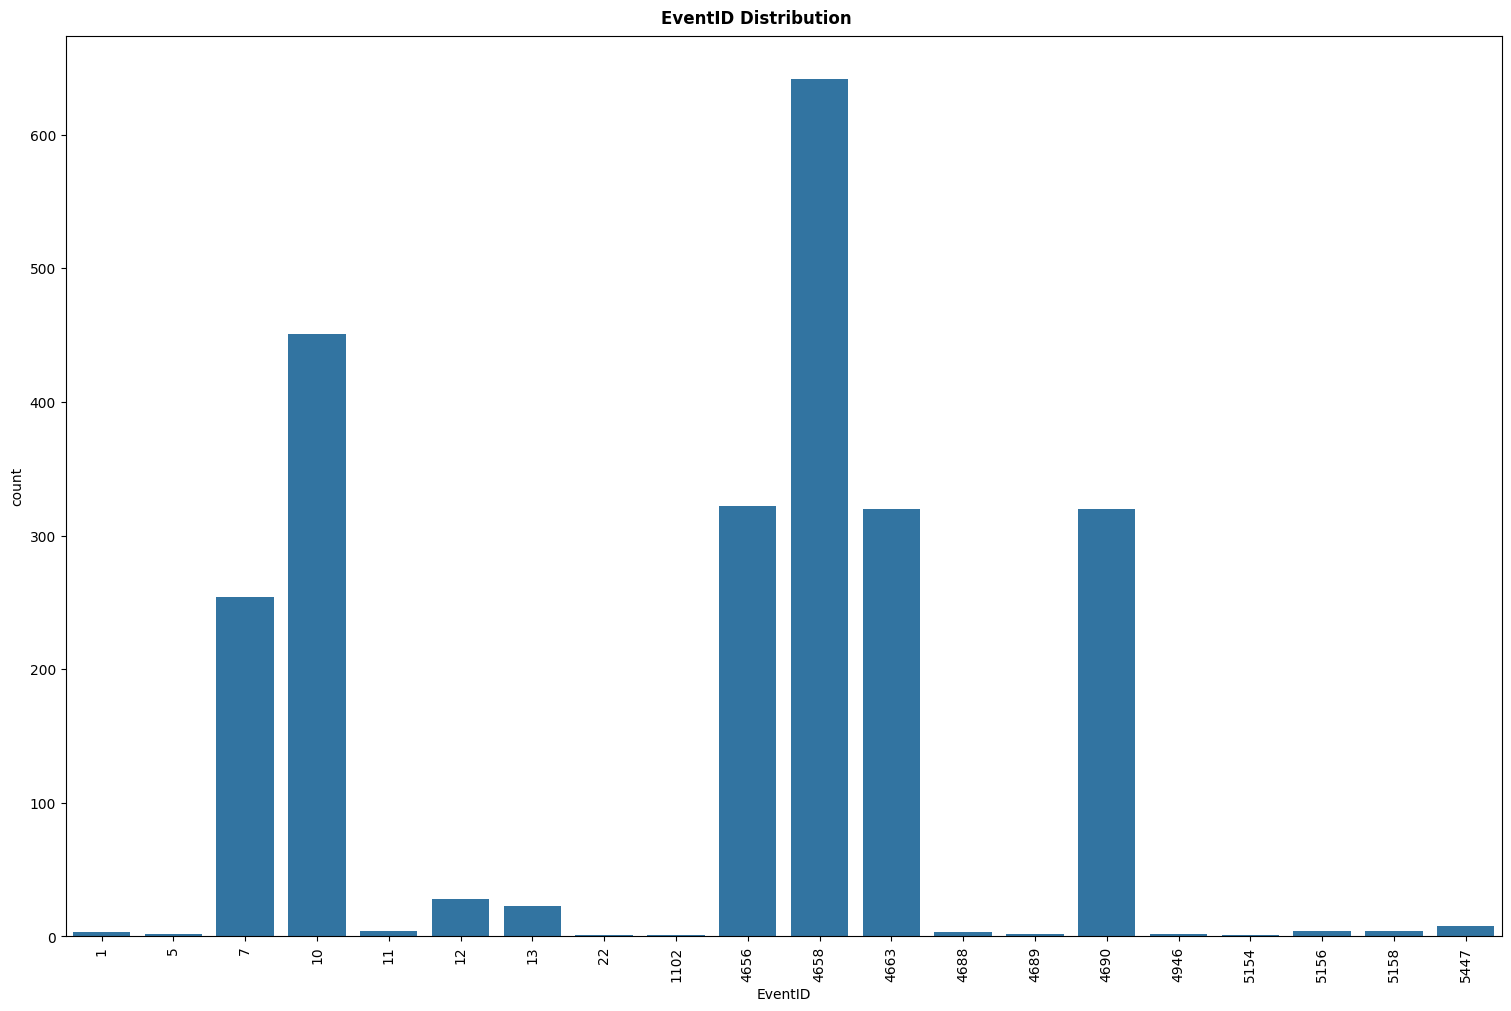

In [46]:
# Event Distribution
fig, ax = plt.subplots(figsize=(15, 10), layout='constrained') # figsize = (x, y)
fig.suptitle('EventID Distribution', fontweight='bold', fontsize='large')
sns.countplot(data=exe_data, x='EventID', ax=ax)
plt.xticks(rotation=90)
plt.show()

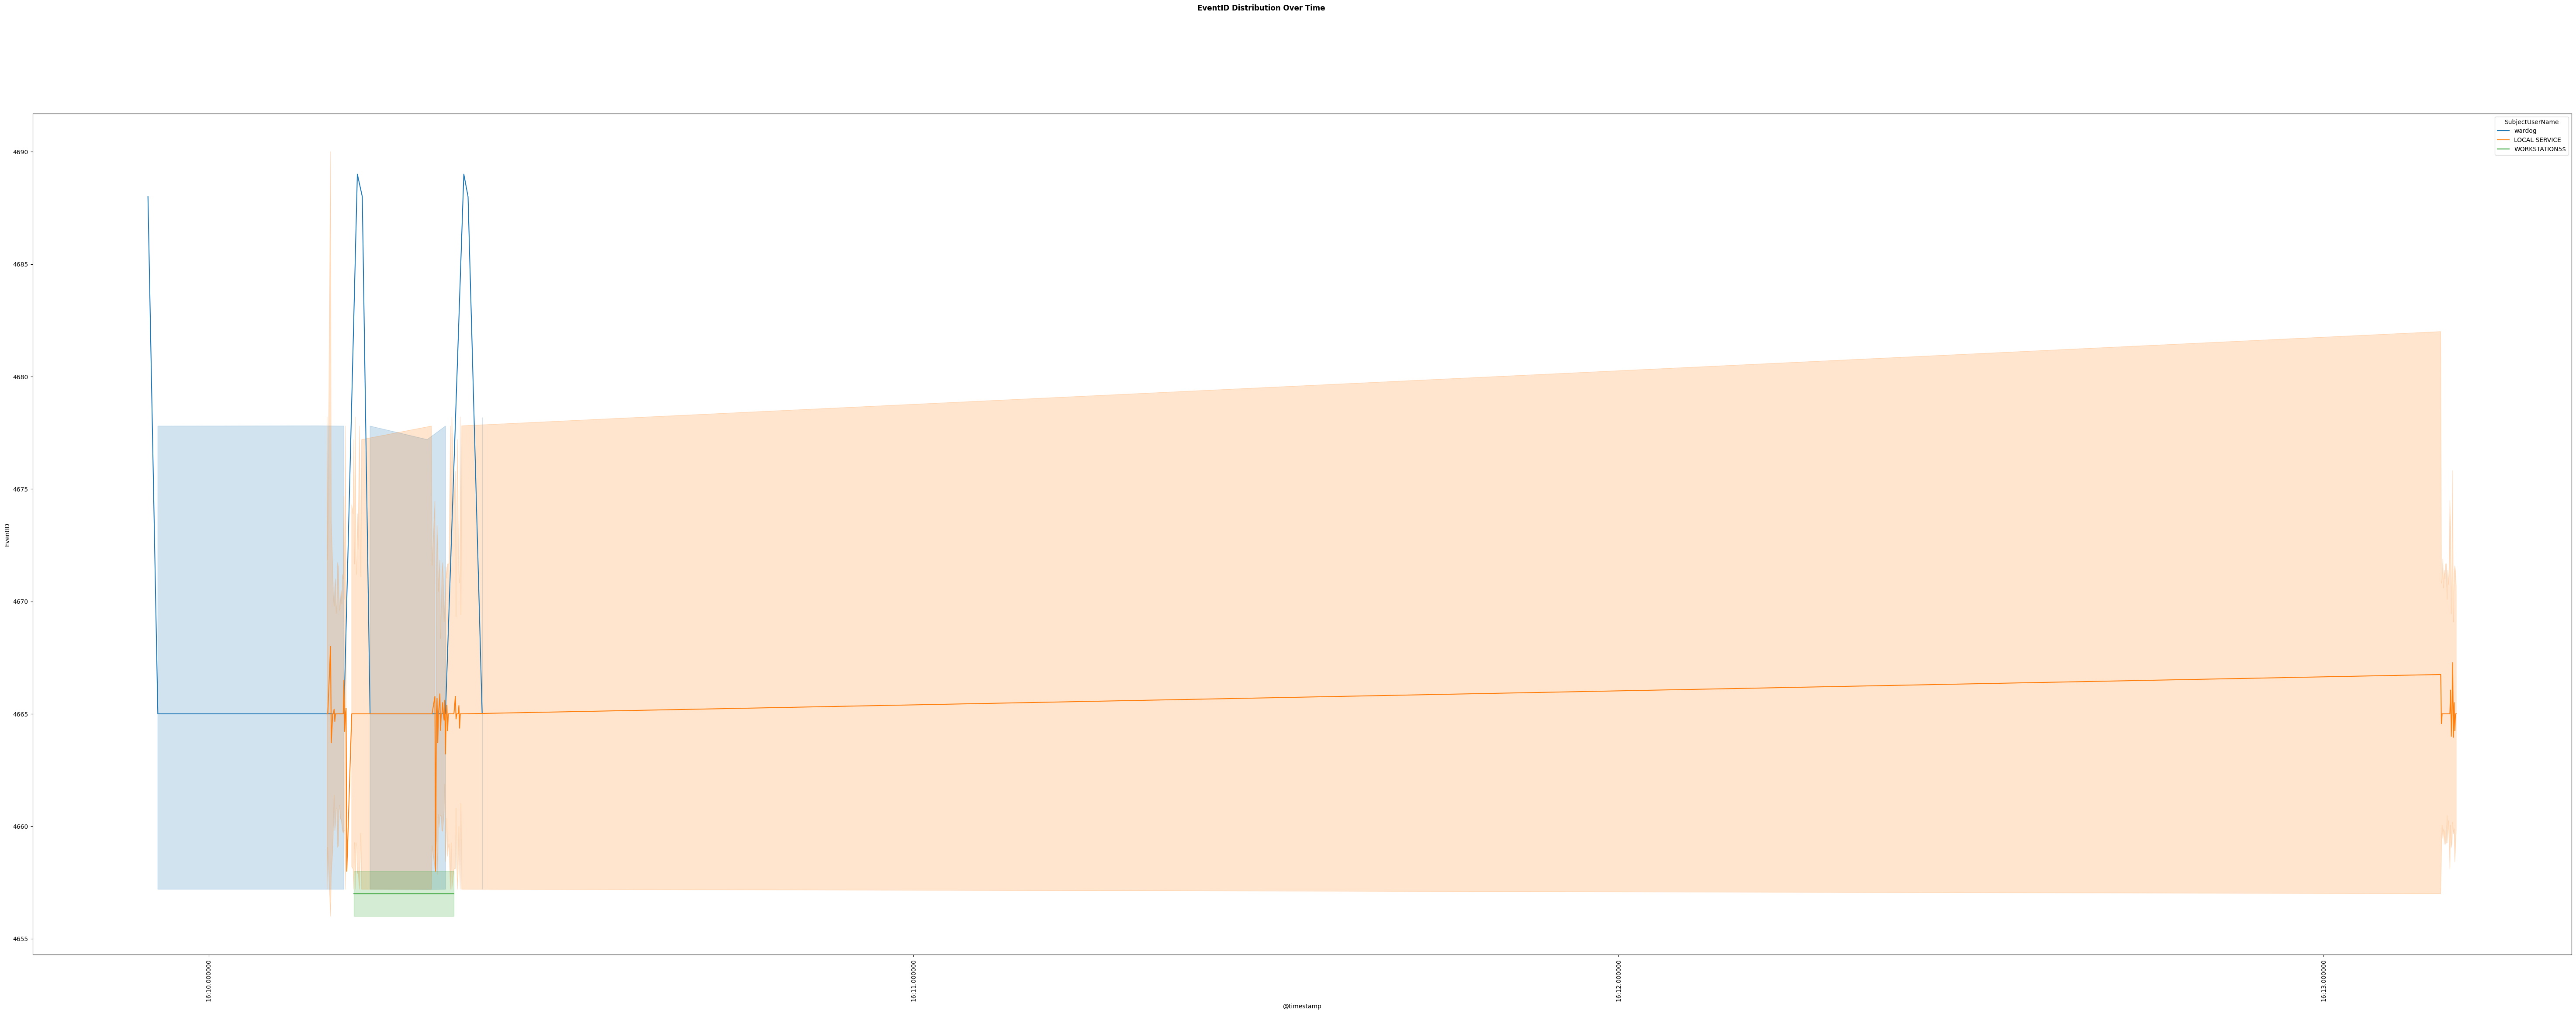

In [47]:
# Time-Based Activity
fig, ax = plt.subplots(figsize=(75, 25)) # figsize = (x, y)
fig.suptitle('EventID Distribution Over Time', fontweight='bold', fontsize='large')
sns.lineplot(data=exe_data, x='@timestamp', y='EventID', hue='SubjectUserName')

plt.xticks(rotation=90)
plt.show()

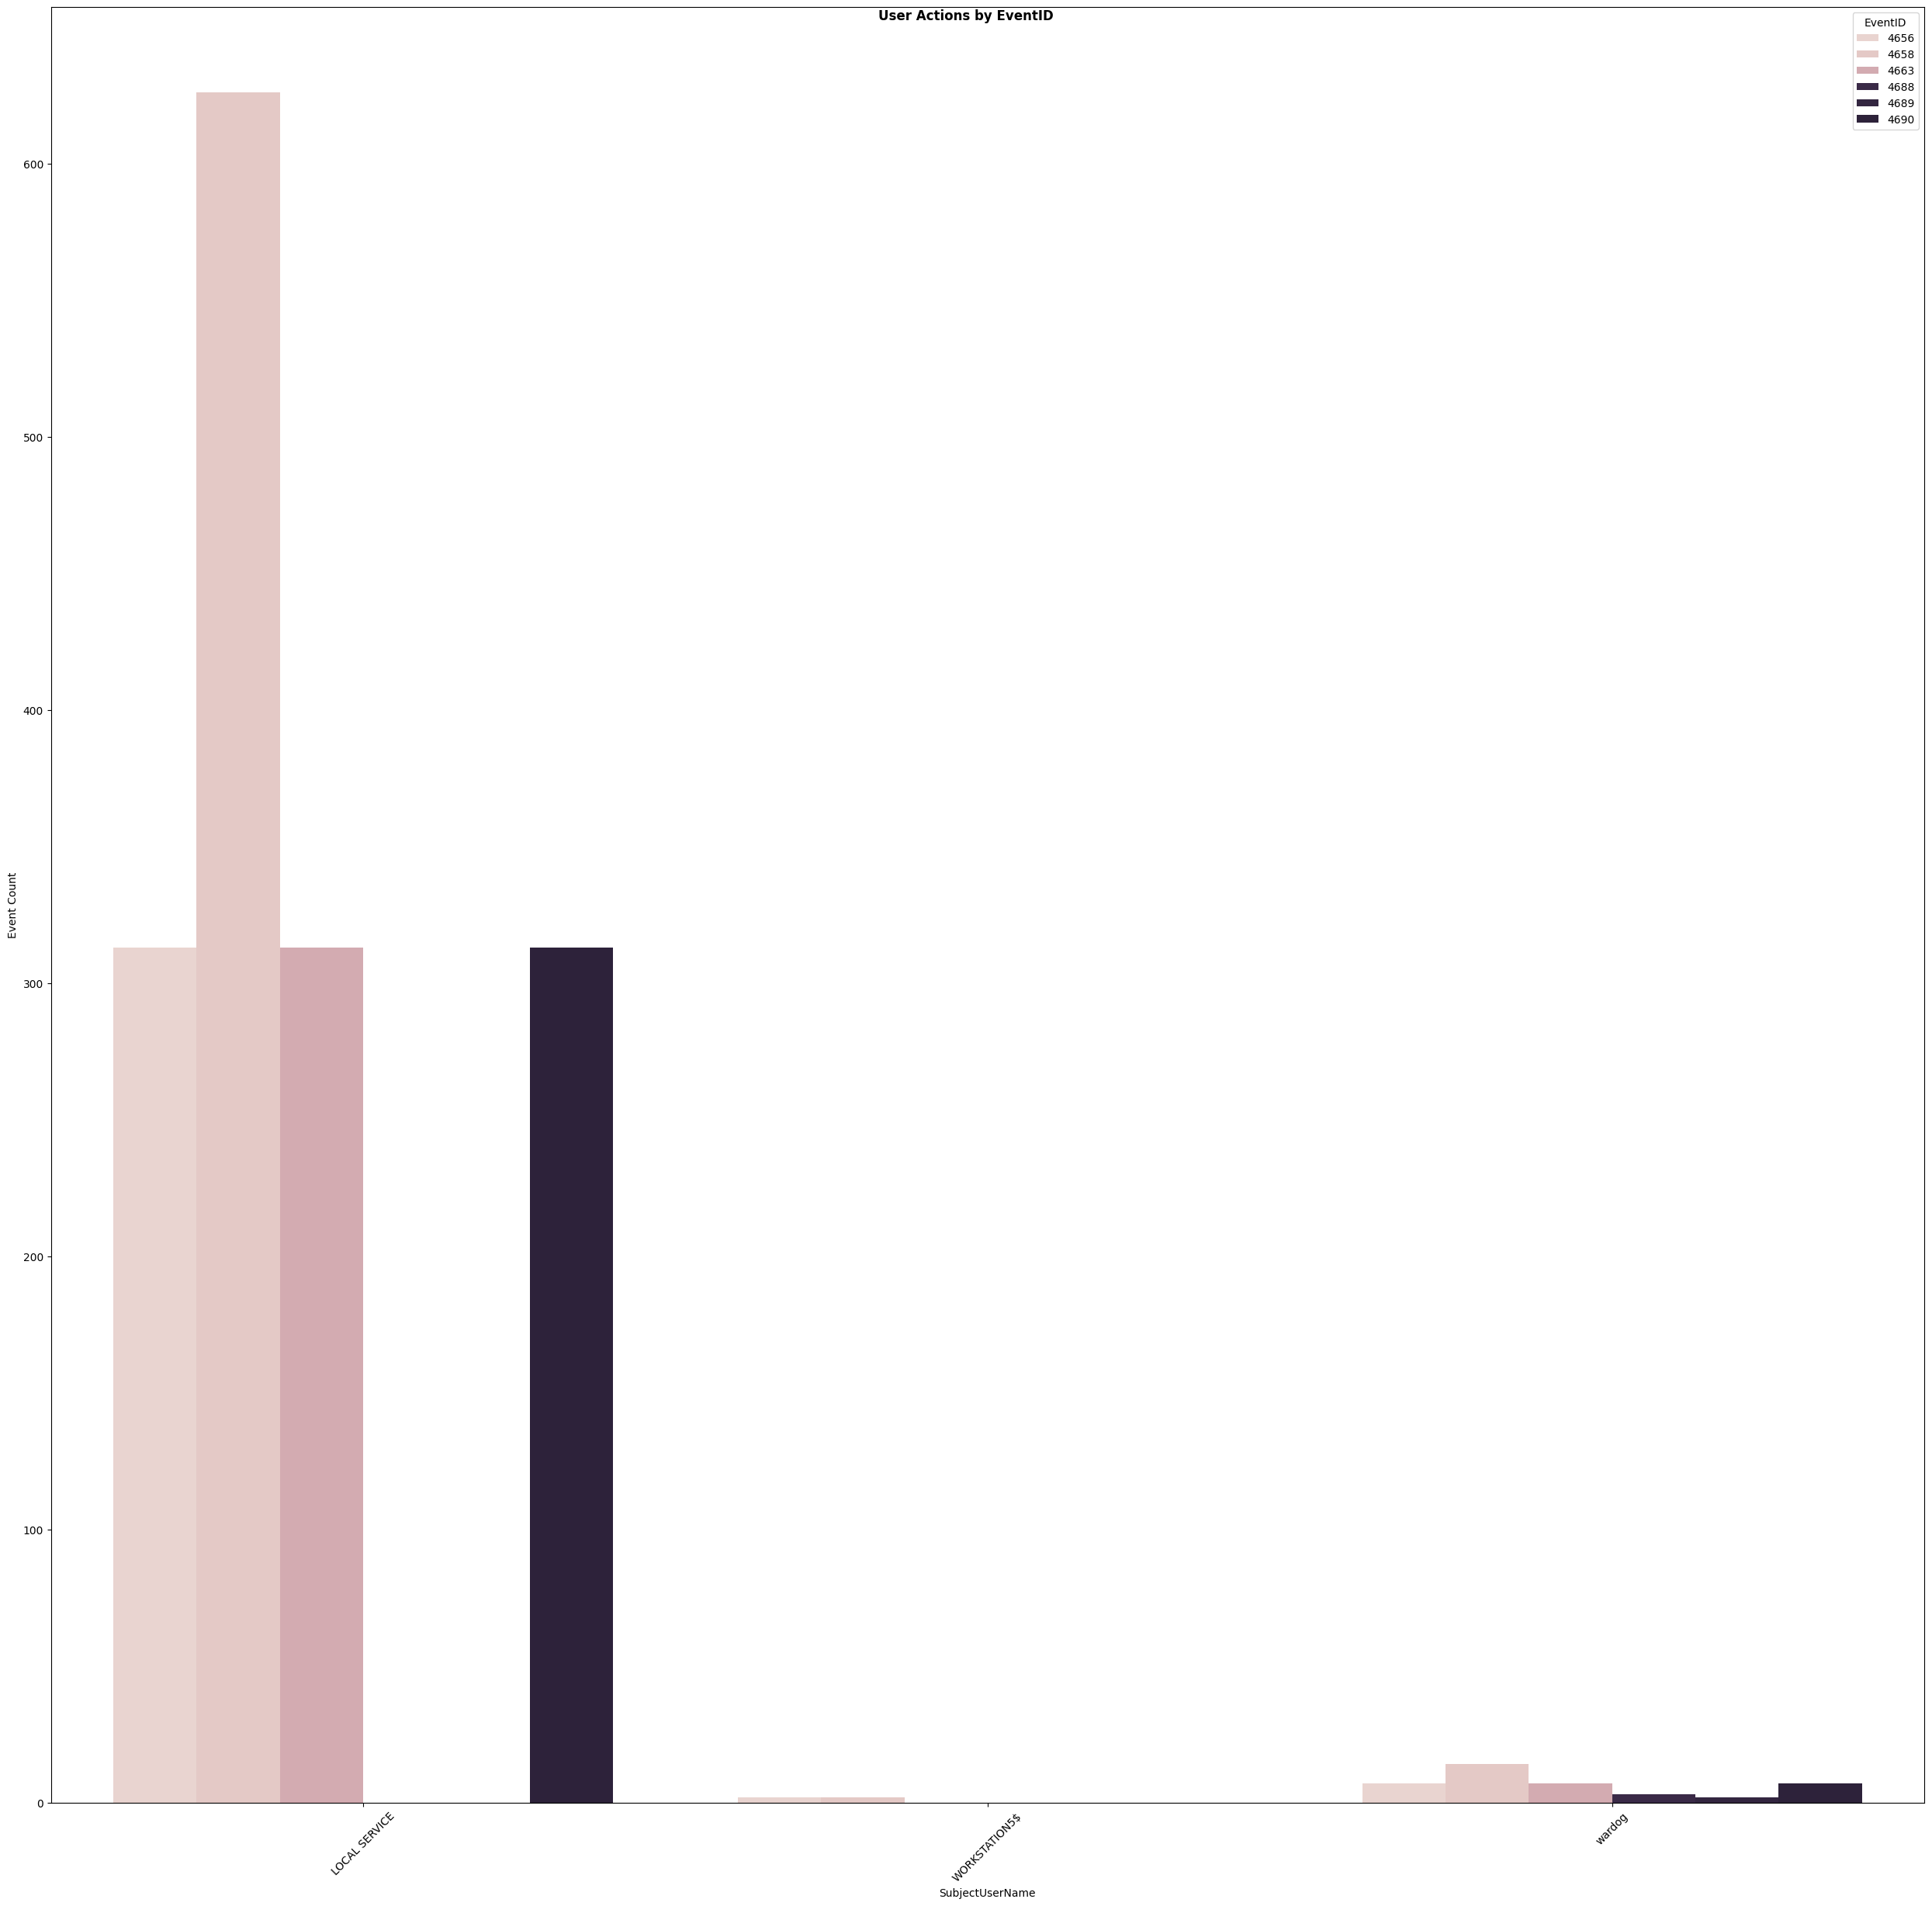

In [48]:
# User Activity
fig, ax = plt.subplots(figsize=(25, 25)) # figsize = (x, y)
fig.suptitle('User Actions by EventID', fontweight='bold', fontsize='large')
grouped = exe_data.groupby(['SubjectUserName', 'EventID']) \
                  .size() \
                  .reset_index(name='count')

sns.barplot(
    data=grouped,
    x='SubjectUserName',
    y='count',
    hue='EventID'
)

plt.xticks(rotation=45)
plt.xlabel('SubjectUserName')
plt.ylabel('Event Count')

plt.legend(title='EventID')
plt.tight_layout()
plt.show()

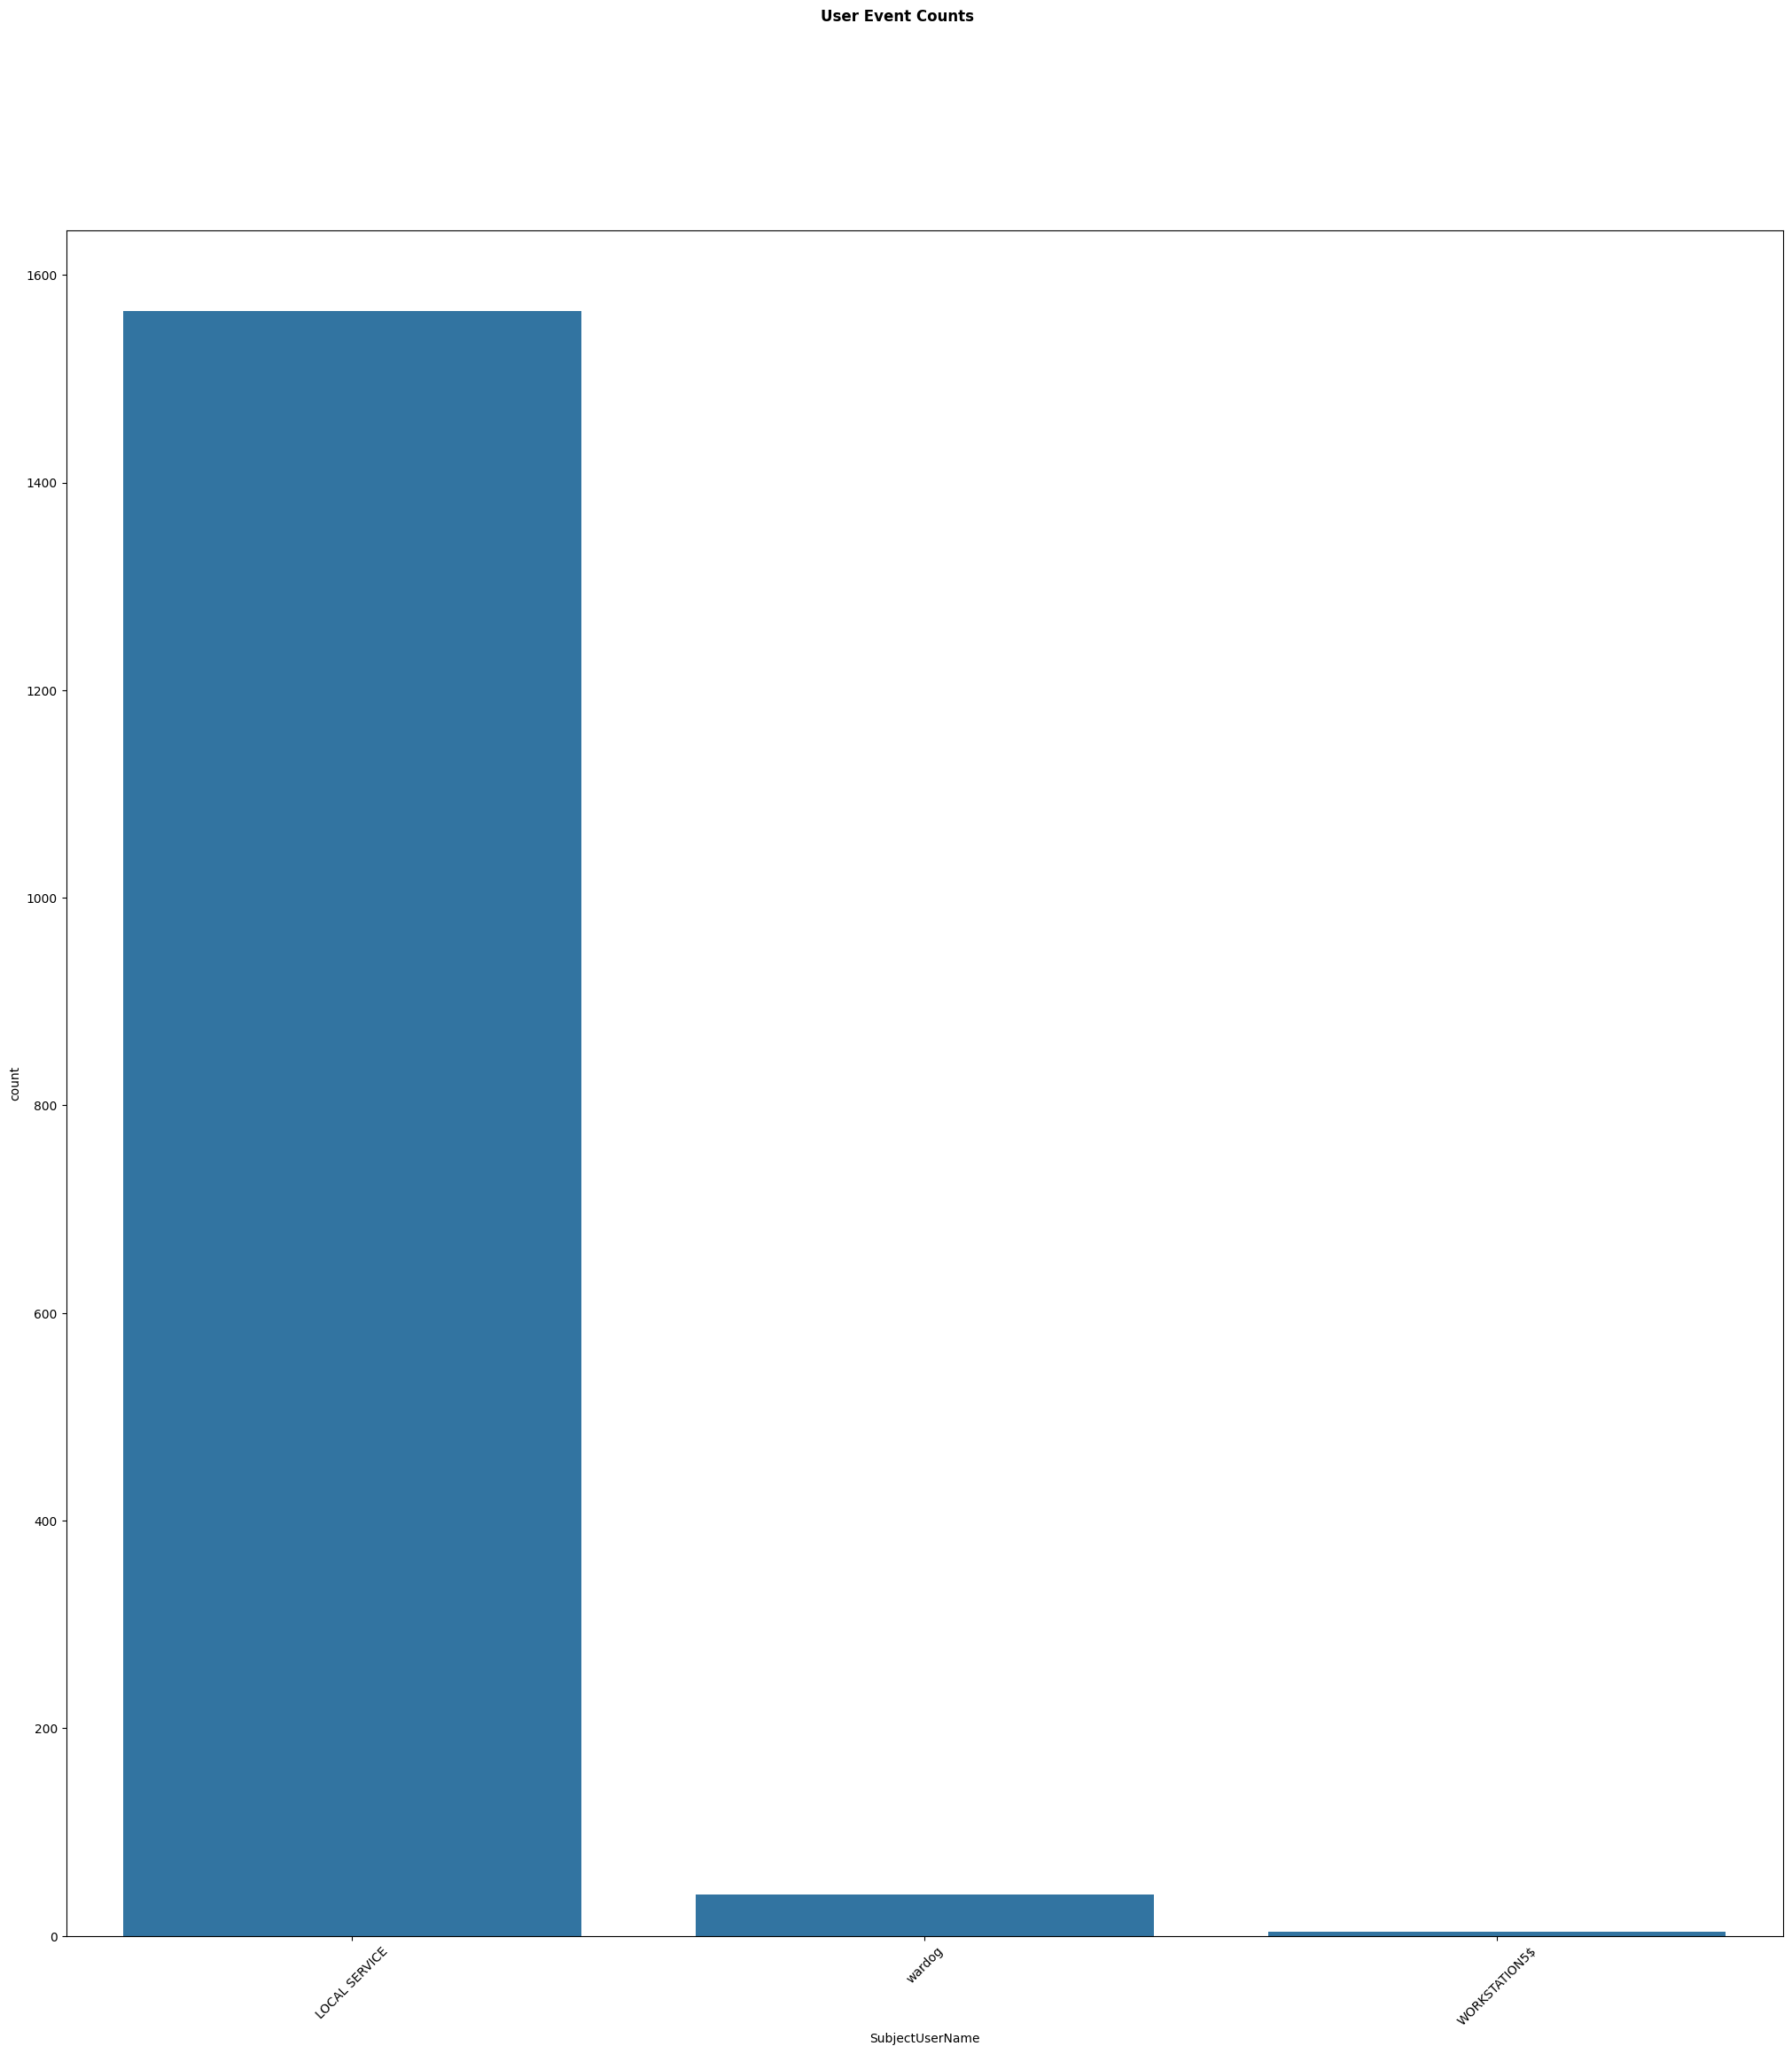

In [49]:
counts = exe_data['SubjectUserName'].value_counts().reset_index()
counts.columns = ['SubjectUserName', 'count']

fig, ax = plt.subplots(figsize=(25, 25)) # figsize = (x, y)
fig.suptitle('User Event Counts', fontweight='bold', fontsize='large')
sns.barplot(data=counts, x='SubjectUserName', y='count')

plt.xticks(rotation=45)
plt.show()

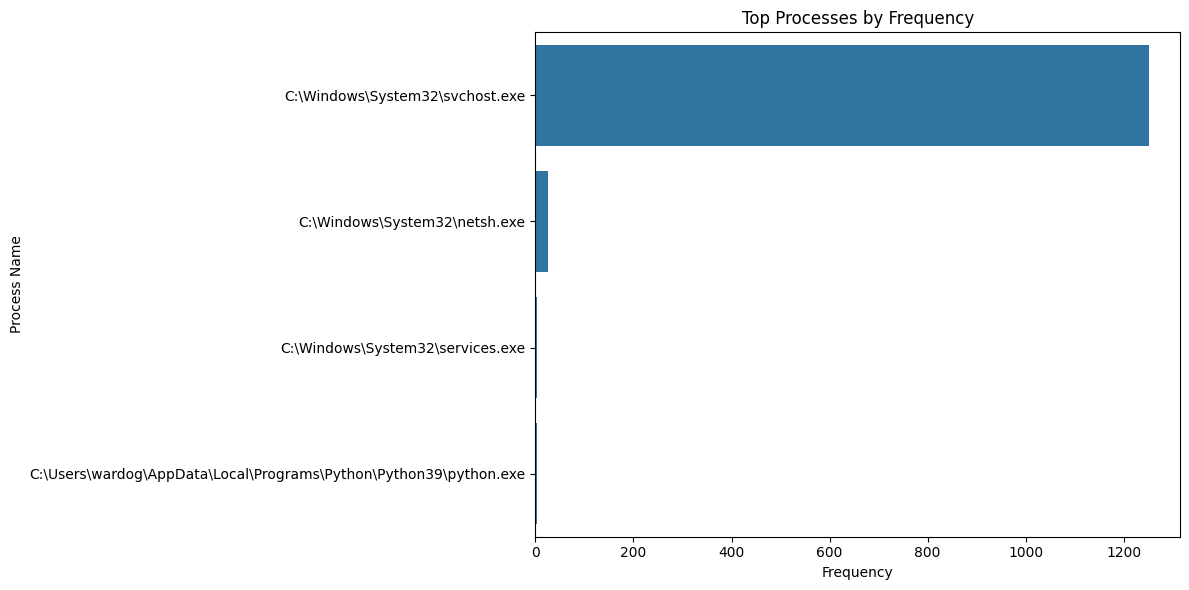

In [50]:
# Process Behavior
process_counts = exe_data['ProcessName'].value_counts().reset_index()
process_counts.columns = ['ProcessName', 'Frequency']

# Bar plot
plt.figure(figsize=(12,6))
sns.barplot(data=process_counts, x='Frequency', y='ProcessName')
plt.title('Top Processes by Frequency')
plt.xlabel('Frequency')
plt.ylabel('Process Name')
plt.tight_layout()
plt.show()

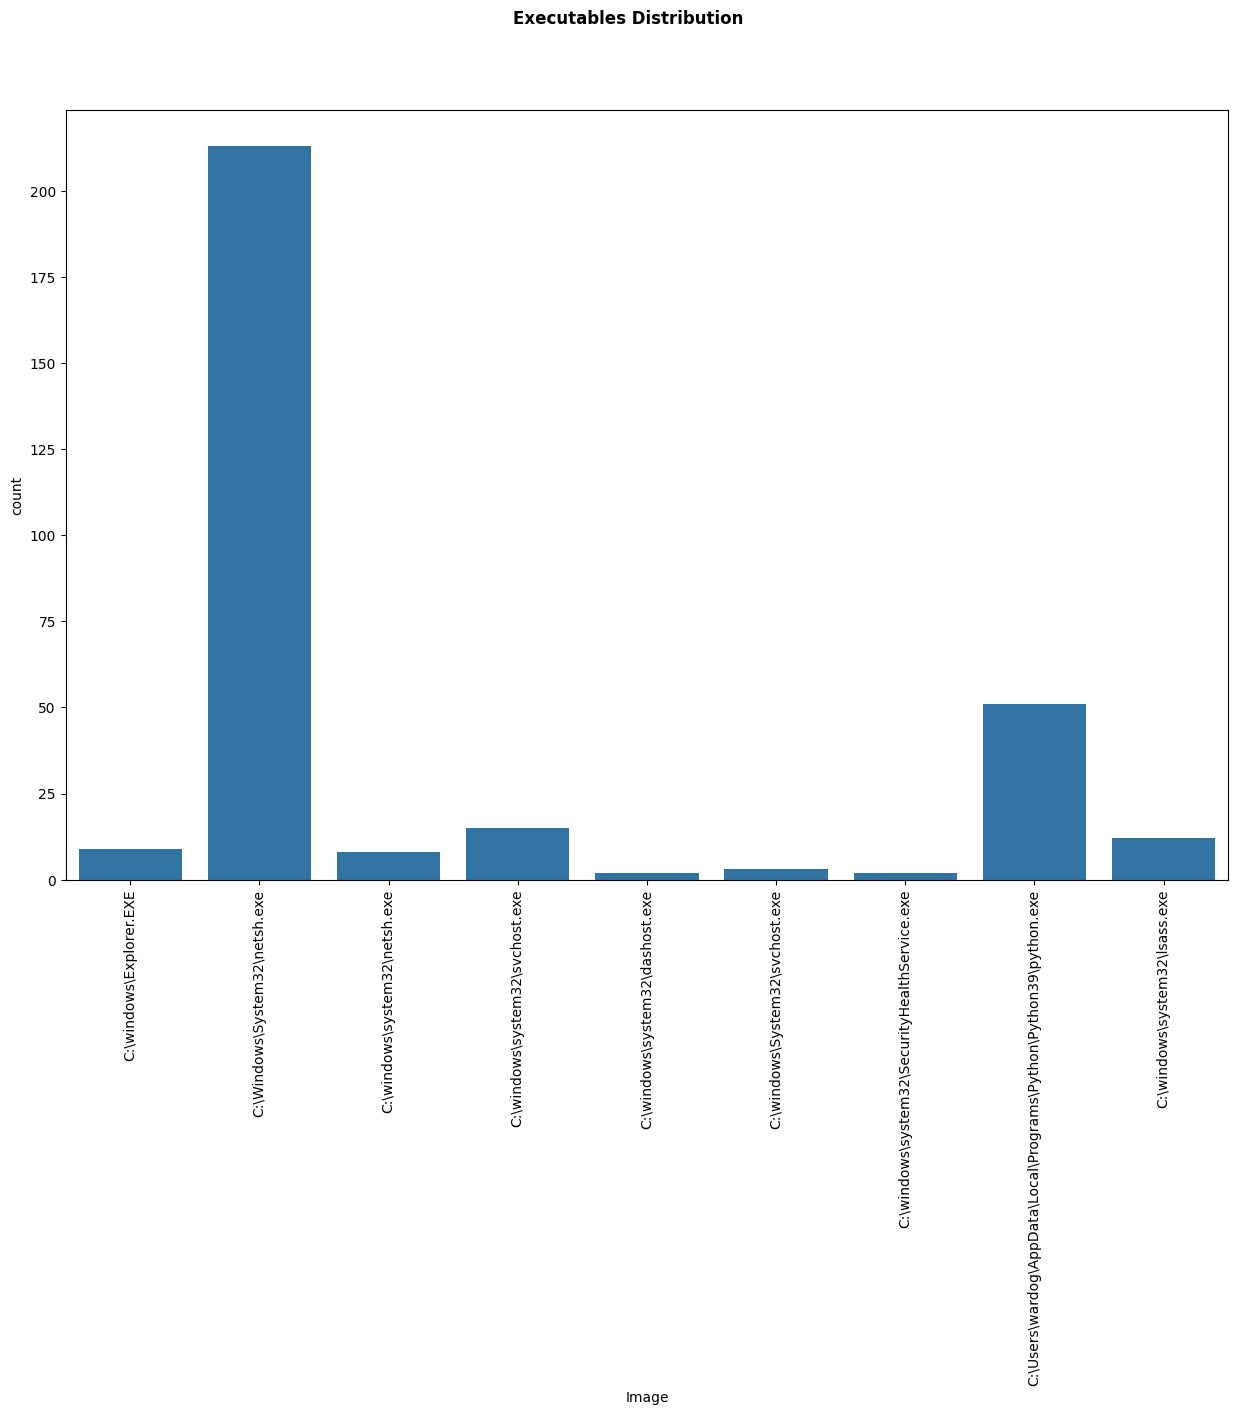

In [51]:
# Executable Distribution 
fig, ax = plt.subplots(figsize=(15, 10)) # figsize = (x, y)
fig.suptitle('Executables Distribution', fontweight='bold', fontsize='large')
sns.countplot(data=exe_data, x='Image', ax=ax)
plt.xticks(rotation=90)
plt.show()

### Execution Log Modeling

## Credential Access Logs

In [52]:
# Reading the logs from the credential access URL
zipFileRequest = requests.get(cred_url)
zipFile = ZipFile(BytesIO(zipFileRequest.content))
datasetJSONPath = zipFile.extract(zipFile.namelist()[0])

# Storing logs into a dataframe
cred_df = pd.read_json(path_or_buf=datasetJSONPath, lines=True)

### Credential Access Log Exploratory Data Analysis

In [53]:
# Sorting the logs by timestamp in ascending order
cred_data = cred_df.sort_values(by='@timestamp', ascending=True)

# Get all columns in the dataset
cred_columns = cred_data.columns.tolist()
cred_columns 

['tags',
 'TargetProcessGUID',
 '@version',
 'EventType',
 'Version',
 'ThreadID',
 'EventTime',
 'Task',
 'AccountType',
 'SourceProcessGUID',
 'CallTrace',
 'Channel',
 'SourceName',
 'OpcodeValue',
 'Hostname',
 '@timestamp',
 'Message',
 'SourceModuleName',
 'ProcessId',
 'SourceImage',
 'EventReceivedTime',
 'port',
 'AccountName',
 'UtcTime',
 'GrantedAccess',
 'Domain',
 'ExecutionProcessID',
 'host',
 'SourceProcessId',
 'SourceThreadId',
 'Severity',
 'TargetProcessId',
 'SeverityValue',
 'EventID',
 'UserID',
 'ProviderGuid',
 'RecordNumber',
 'SourceModuleType',
 'Keywords',
 'TargetImage',
 'RuleName',
 'EventTypeOrignal',
 'TargetObject',
 'Image',
 'ProcessGuid',
 'SourcePort',
 'Category',
 'Opcode',
 'Application',
 'LayerRTID',
 'LayerName',
 'SourceAddress',
 'FilterRTID',
 'Protocol',
 'DestAddress',
 'Direction',
 'RemoteMachineID',
 'DestPort',
 'RemoteUserID',
 'DestinationPortName',
 'DestinationIp',
 'SourceIp',
 'Initiated',
 'DestinationHostname',
 'SourceHost

In [54]:
# Algorithm to count the number of occurrences of each value in each feature and save it to a text file
'''for feature in cred_data.columns.to_list():
    count = cred_data[feature].value_counts()

    # Replace spaces in feature names to avoid invalid filenames
    safe_feature_name = feature.replace(" ", "_")

    with open(f"{safe_feature_name}.txt", "w") as f:
        f.write(count.to_string())'''

'for feature in cred_data.columns.to_list():\n    count = cred_data[feature].value_counts()\n\n    # Replace spaces in feature names to avoid invalid filenames\n    safe_feature_name = feature.replace(" ", "_")\n\n    with open(f"{safe_feature_name}.txt", "w") as f:\n        f.write(count.to_string())'

### Credential Access Log Data Visualization

### Credential Access Log Modeling